# 🎯 Kaggle Job Recommendation System
## Complete ML Pipeline

**Techniques:** TF-IDF Vectorization + Cosine Similarity

**Dataset:** AI-Powered Job Recommendations (50,000 jobs)

---

### Execution Flow
1. Load Dataset
2. Data Preprocessing
3. Feature Engineering (TF-IDF)
4. User Input
5. Recommendation Generation
6. Automatic Evaluation
7. Graph Generation
8. Results & Analysis

## 📦 Install Dependencies

In [18]:
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib -q

## 📚 Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import re
import time
from collections import Counter
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

print('All libraries imported successfully! ✓')

All libraries imported successfully! ✓


## 🔌 Kaggle Dataset Adapter
Converts the Kaggle dataset columns to the internal format used by the recommendation system.

In [20]:
"""
Kaggle Dataset Adapter Module
==============================

Converts the Kaggle "AI-Powered Job Recommendations Dataset" to the 
internal format used by the recommendation system.

Dataset: AI-Powered Job Recommendations Dataset
Columns: Job Title, Company, Location, Experience Level, Salary, Industry, Required Skills
Records: 50,000 job postings

Author: ML Engineer
Date: 2026-04-12
"""

import pandas as pd
import numpy as np
import os
from pathlib import Path


class KaggleDatasetAdapter:
    """Adapter to transform Kaggle dataset into recommendation system format."""
    
    @staticmethod
    def load_kaggle_dataset(file_path, sample=None):
        """
        Load and adapt Kaggle dataset.
        
        Args:
            file_path (str): Path to Kaggle CSV file
            sample (int): If specified, return random sample of N rows
            
        Returns:
            pd.DataFrame: Adapted dataset with columns:
                - job_title: Job role
                - required_skills: Comma-separated skills
                - industry: Industry sector
                - location: Job location
                - experience_level: Career level
                - company: Hiring company
        """
        print(f"Loading Kaggle dataset from {file_path}...")
        
        # Load CSV
        df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')
        
        print(f"Original dataset shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        
        # Standardize column names (handle different casings)
        df.columns = df.columns.str.strip().str.lower()
        
        print(f"\nStandardized columns: {list(df.columns)}")
        
        # Map Kaggle columns to internal format
        adapted_df = pd.DataFrame()
        
        # Job Title - required
        if 'job title' in df.columns:
            adapted_df['job_title'] = df['job title'].fillna('Unknown Job')
        else:
            raise ValueError("'Job Title' column required in dataset")
        
        # Required Skills - required (may be called 'skills' or 'required skills')
        if 'required skills' in df.columns:
            adapted_df['required_skills'] = df['required skills'].fillna('')
        elif 'skills' in df.columns:
            adapted_df['required_skills'] = df['skills'].fillna('')
        else:
            raise ValueError("'Required Skills' column required in dataset")
        
        # Industry - optional but useful for corpus
        adapted_df['industry'] = df['industry'].fillna('') if 'industry' in df.columns else ''
        
        # Location - optional
        adapted_df['location'] = df['location'].fillna('') if 'location' in df.columns else ''
        
        # Experience Level - optional
        adapted_df['experience_level'] = df['experience level'].fillna('') if 'experience level' in df.columns else ''
        
        # Company - optional
        adapted_df['company'] = df['company'].fillna('') if 'company' in df.columns else ''
        
        # Salary - optional (useful for analysis)
        if 'salary' in df.columns:
            adapted_df['salary'] = df['salary']
        else:
            adapted_df['salary'] = np.nan
        
        # Remove rows with no job title or skills
        initial_count = len(adapted_df)
        adapted_df = adapted_df[
            (adapted_df['job_title'].notna()) &
            (adapted_df['job_title'] != '') &
            (adapted_df['required_skills'].notna()) &
            (adapted_df['required_skills'] != '')
        ].reset_index(drop=True)
        
        print(f"\nRemoved {initial_count - len(adapted_df)} rows with missing data")
        print(f"Final dataset shape: {adapted_df.shape}")
        print(f"\nSample rows:")
        print(adapted_df.head(3))
        
        # Optionally sample for faster processing
        if sample and sample < len(adapted_df):
            adapted_df = adapted_df.sample(n=sample, random_state=42).reset_index(drop=True)
            print(f"\nSampled to {len(adapted_df)} rows")
        
        return adapted_df
    
    @staticmethod
    def create_corpus(df):
        """
        Create text corpus by combining relevant job fields.
        
        Args:
            df (pd.DataFrame): Adapted dataset
            
        Returns:
            pd.Series: Combined text corpus for each job
        """
        print("\nCreating text corpus...")
        
        # Combine fields: job_title + industry + required_skills
        # Weight is implicit: all fields treated equally
        corpus = (
            df['job_title'].astype(str).str.lower() + ' ' +
            df['industry'].astype(str).str.lower() + ' ' +
            df['required_skills'].astype(str).str.lower()
        )
        
        # Clean up extra spaces
        corpus = corpus.str.replace(r'\s+', ' ', regex=True).str.strip()
        
        print(f"Corpus created: {len(corpus)} documents")
        print(f"\nSample corpus entries:")
        for i in range(min(3, len(corpus))):
            preview = corpus.iloc[i][:100] + "..."
            print(f"  [{i}] {preview}")
        
        return corpus
    
    @staticmethod
    def extract_skill_stats(df):
        """
        Extract insights from skills data.
        
        Args:
            df (pd.DataFrame): Adapted dataset
            
        Returns:
            dict: Skill statistics
        """
        print("\nExtracting skill statistics...")
        
        # Split skills and count frequency
        all_skills = []
        for skills_str in df['required_skills'].dropna():
            if isinstance(skills_str, str) and skills_str.strip():
                skills = [s.strip() for s in skills_str.split(',')]
                all_skills.extend(skills)
        
        # Count skill frequency
        from collections import Counter
        skill_counts = Counter(all_skills)
        top_skills = skill_counts.most_common(20)
        
        print(f"\nTotal unique skills: {len(skill_counts)}")
        print(f"Top 10 most common skills:")
        for skill, count in top_skills[:10]:
            print(f"  • {skill}: {count} jobs")
        
        return {
            'total_unique_skills': len(skill_counts),
            'top_skills': top_skills,
            'skill_counts': skill_counts
        }
    
    @staticmethod
    def extract_experience_stats(df):
        """
        Extract insights from experience level data.
        
        Args:
            df (pd.DataFrame): Adapted dataset
            
        Returns:
            dict: Experience level statistics
        """
        if 'experience_level' not in df.columns or df['experience_level'].empty:
            return {}
        
        exp_counts = df['experience_level'].value_counts()
        print(f"\nExperience levels in dataset:")
        for exp_level, count in exp_counts.items():
            if exp_level and str(exp_level).strip():
                print(f"  • {exp_level}: {count} jobs")
        
        return exp_counts.to_dict()
    
    @staticmethod
    def save_adapted_dataset(df, output_path):
        """
        Save adapted dataset locally.
        
        Args:
            df (pd.DataFrame): Adapted dataset
            output_path (str): Path to save CSV
        """
        df.to_csv(output_path, index=False)
        print(f"\n✓ Adapted dataset saved to {output_path}")


# ============================================================================
# CONVENIENT FUNCTION FOR QUICK LOADING
# ============================================================================

def load_and_adapt_kaggle_dataset(kaggle_file_path, sample=None):
    """
    Convenience function to load and adapt Kaggle dataset in one call.
    
    Args:
        kaggle_file_path (str): Path to Kaggle CSV
        sample (int): Optional - return random sample of N rows
        
    Returns:
        tuple: (adapted_df, corpus, skill_stats, experience_stats)
    """
    # Load and adapt
    adapter = KaggleDatasetAdapter()
    df = adapter.load_kaggle_dataset(kaggle_file_path, sample=sample)
    
    # Create corpus
    corpus = adapter.create_corpus(df)
    
    # Extract statistics
    skill_stats = adapter.extract_skill_stats(df)
    experience_stats = adapter.extract_experience_stats(df)
    
    return df, corpus, skill_stats, experience_stats


## 🤖 Job Recommendation System (Core ML Engine)
TF-IDF vectorization and cosine similarity based recommendation engine.

In [21]:
"""
Job Recommendation System - ML Module (Kaggle Dataset Version)
==============================================================

A production-quality machine learning module for recommending jobs based on user skills.
Adapted to work with the Kaggle "AI-Powered Job Recommendations Dataset" (50,000 jobs).

Features:
- Kaggle dataset loading and adaptation
- Text preprocessing and cleaning
- TF-IDF vectorization
- Cosine similarity-based recommendations
- Model persistence using joblib
- Skill matching and explanation

Author: ML Engineer
Date: 2026-04-12
"""

import pandas as pd
import numpy as np
import joblib
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
from pathlib import Path
# KaggleDatasetAdapter already defined above


class JobRecommendationSystem:
    """
    A machine learning-based job recommendation system.
    
    Uses TF-IDF vectorization and cosine similarity to recommend
    the most relevant jobs based on user skills and preferences.
    Supports both small sample datasets and large Kaggle datasets.
    """
    
    def __init__(self, model_dir='models'):
        """
        Initialize the Job Recommendation System.
        
        Args:
            model_dir (str): Directory to store trained models
        """
        self.model_dir = model_dir
        self.vectorizer = None
        self.job_vectors = None
        self.jobs_data = None
        self.jobs_corpus = None
        self.adapter = KaggleDatasetAdapter()
        
        # Create model directory if it doesn't exist
        Path(self.model_dir).mkdir(exist_ok=True, parents=True)
    
    # ==================== DATA LOADING ====================
    def load_kaggle_dataset(self, file_path, sample=None):
        """
        Load and adapt Kaggle job recommendations dataset.
        
        Args:
            file_path (str): Path to Kaggle CSV file
            sample (int): Optional - use random sample of N rows for faster processing
            
        Returns:
            pd.DataFrame: Adapted dataset with standardized columns
        """
        # Use adapter to load and standardize
        self.jobs_data = self.adapter.load_kaggle_dataset(file_path, sample=sample)
        
        # Create corpus
        self.jobs_corpus = self.adapter.create_corpus(self.jobs_data)
        
        return self.jobs_data
    
    def load_data(self, file_path):
        """
        Load job dataset from CSV file.
        Supports both sample datasets and Kaggle dataset.
        
        Args:
            file_path (str): Path to the CSV file
            
        Returns:
            pd.DataFrame: Loaded dataset
            
        Raises:
            FileNotFoundError: If file doesn't exist
        """
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Dataset not found at {file_path}")
        
        # Load CSV file
        df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')
        
        # Check if it's Kaggle format (has 'Job Title' column with capitals)
        if 'Job Title' in df.columns or 'job title' in df.columns.str.lower().tolist():
            print("Detected Kaggle dataset format - using adapter...")
            return self.load_kaggle_dataset(file_path)
        
        # Otherwise, assume it's the sample format with standardized columns
        print("Detected sample dataset format")
        
        # Standardize column names
        df.columns = df.columns.str.strip().str.lower()
        
        # Validate required columns
        required_columns = ['job_title', 'required_skills']
        missing = [col for col in required_columns if col not in df.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")
        
        # Handle missing values
        df['required_skills'] = df['required_skills'].fillna('')
        df['job_title'] = df['job_title'].fillna('Unknown')
        
        # Add optional columns if present
        if 'industry' not in df.columns:
            df['industry'] = ''
        if 'location' not in df.columns:
            df['location'] = ''
        if 'experience_level' not in df.columns:
            df['experience_level'] = ''
        if 'company' not in df.columns:
            df['company'] = ''
        
        # Store data
        self.jobs_data = df.reset_index(drop=True)
        
        # Create corpus
        self.jobs_corpus = self.adapter.create_corpus(self.jobs_data)
        
        print(f"✓ Loaded {len(self.jobs_data)} jobs from dataset")
        return self.jobs_data
    
    # ==================== TEXT PREPROCESSING ====================
    @staticmethod
    def preprocess_text(text):
        """
        Clean and preprocess text data.
        
        Steps:
        1. Convert to lowercase
        2. Remove special characters and punctuation
        3. Remove extra whitespace
        4. Preserve words (only remove non-alphanumeric except spaces)
        """
        if not isinstance(text, str):
            return ""
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove special characters but keep alphanumeric and spaces
        text = re.sub(r'[^a-z0-9\s]', '', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    # ==================== VECTORIZATION ====================
    def vectorize_data(self, min_df=1, max_df=0.95, max_features=1500):
        """
        Apply TF-IDF vectorization to the corpus.
        
        Args:
            min_df (int): Minimum document frequency
            max_df (float): Maximum document frequency (0-1 scale)
            max_features (int): Maximum number of features
            
        Returns:
            scipy.sparse matrix: Document-term matrix
        """
        print(f"\nApplying TF-IDF vectorization...")
        print(f"  - min_df: {min_df}")
        print(f"  - max_df: {max_df}")
        print(f"  - max_features: {max_features}")
        
        # Preprocess corpus
        processed_corpus = [self.preprocess_text(doc) for doc in self.jobs_corpus]
        
        # Create vectorizer
        self.vectorizer = TfidfVectorizer(
            min_df=min_df,
            max_df=max_df,
            max_features=max_features,
            stop_words='english'
        )
        
        # Fit and transform
        self.job_vectors = self.vectorizer.fit_transform(processed_corpus)
        
        print(f"✓ Vectorized {self.job_vectors.shape[0]} documents")
        print(f"✓ Created {self.job_vectors.shape[1]}-dimensional feature space")
        
        return self.job_vectors
    
    # ==================== RECOMMENDATION ENGINE ====================
    def recommend_jobs(self, user_input, top_k=5, explain=True):
        """
        Recommend top-K jobs based on user input (skills).
        
        Args:
            user_input (str): User input describing desired job/skills
            top_k (int): Number of recommendations to return
            explain (bool): If True, include matched skills
            
        Returns:
            list: List of dicts with recommendations
                {
                    'job_id': int,
                    'job_title': str,
                    'company': str,
                    'location': str,
                    'similarity_score': float,
                    'matched_skills': str (if explain=True)
                }
        """
        if self.vectorizer is None or self.job_vectors is None:
            raise ValueError("System not trained. Call vectorize_data() first.")
        
        # Preprocess user input
        processed_input = self.preprocess_text(user_input)
        
        # Transform user input using same vectorizer
        user_vector = self.vectorizer.transform([processed_input])
        
        # Compute cosine similarity with all jobs
        similarities = cosine_similarity(user_vector, self.job_vectors)[0]
        
        # Get top-K indices
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        # Build recommendations list
        recommendations = []
        for idx in top_indices:
            job_info = {
                'job_id': int(idx),
                'job_title': self.jobs_data.loc[idx, 'job_title'],
                'company': self.jobs_data.loc[idx, 'company'] if 'company' in self.jobs_data.columns else 'N/A',
                'location': self.jobs_data.loc[idx, 'location'] if 'location' in self.jobs_data.columns else 'N/A',
                'industry': self.jobs_data.loc[idx, 'industry'] if 'industry' in self.jobs_data.columns else 'N/A',
                'experience_level': self.jobs_data.loc[idx, 'experience_level'] if 'experience_level' in self.jobs_data.columns else 'N/A',
                'similarity_score': float(similarities[idx]),
            }
            
            # Add matched skills if requested
            if explain:
                job_skills = self.jobs_data.loc[idx, 'required_skills']
                user_skills_set = set(s.strip().lower() for s in processed_input.split() if s.strip())
                job_skills_set = set(s.strip().lower() for s in str(job_skills).split(',') if s.strip())
                matched = job_skills_set & user_skills_set
                job_info['matched_skills'] = list(matched) if matched else []
            
            recommendations.append(job_info)
        
        return recommendations
    
    # ==================== MODEL PERSISTENCE ====================
    def save_model(self, name='job_recommender'):
        """
        Save trained model to disk using joblib.
        
        Args:
            name (str): Model name (without extension)
        """
        vectorizer_path = os.path.join(self.model_dir, f'{name}_vectorizer.pkl')
        data_path = os.path.join(self.model_dir, f'{name}_data.pkl')
        
        joblib.dump(self.vectorizer, vectorizer_path)
        joblib.dump({
            'jobs_data': self.jobs_data,
            'jobs_corpus': self.jobs_corpus,
            'job_vectors': self.job_vectors
        }, data_path)
        
        print(f"✓ Model saved to {vectorizer_path}")
        print(f"✓ Data saved to {data_path}")
    
    def load_model(self, name='job_recommender'):
        """
        Load trained model from disk.
        
        Args:
            name (str): Model name (without extension)
        """
        vectorizer_path = os.path.join(self.model_dir, f'{name}_vectorizer.pkl')
        data_path = os.path.join(self.model_dir, f'{name}_data.pkl')
        
        if not os.path.exists(vectorizer_path):
            raise FileNotFoundError(f"Model not found: {vectorizer_path}")
        
        self.vectorizer = joblib.load(vectorizer_path)
        data = joblib.load(data_path)
        
        self.jobs_data = data['jobs_data']
        self.jobs_corpus = data['jobs_corpus']
        self.job_vectors = data['job_vectors']
        
        print(f"✓ Model loaded from {vectorizer_path}")
    
    # ==================== TRAINING PIPELINE ====================
    def train(self, data_path, sample=None):
        """
        Complete training pipeline.
        
        Args:
            data_path (str): Path to dataset CSV
            sample (int): Optional - use random sample of N rows
            
        Returns:
            dict: Training summary
        """
        print("="*70)
        print("TRAINING JOB RECOMMENDATION SYSTEM")
        print("="*70)
        
        # Load data
        print("\n[1/3] Loading dataset...")
        self.load_data(data_path)
        
        # Vectorize
        print("\n[2/3] Vectorizing corpus...")
        self.vectorize_data()
        
        # Save model
        print("\n[3/3] Saving model...")
        self.save_model()
        
        summary = {
            'total_jobs': len(self.jobs_data),
            'vectorizer_features': self.job_vectors.shape[1],
            'total_documents': self.job_vectors.shape[0],
            'model_size_mb': os.path.getsize(os.path.join(self.model_dir, 'job_recommender_vectorizer.pkl')) / (1024*1024)
        }
        
        print("\n" + "="*70)
        print("TRAINING COMPLETE!")
        print(f"  • Jobs in dataset: {summary['total_jobs']}")
        print(f"  • Features created: {summary['vectorizer_features']}")
        print(f"  • Model size: {summary['model_size_mb']:.2f} MB")
        print("="*70)
        
        return summary


# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def get_skill_stats(jobs_data):
    """Extract and display skill statistics."""
    return KaggleDatasetAdapter.extract_skill_stats(jobs_data)


def display_recommendations(recommendations, show_matched_skills=True):
    """Display recommendations in formatted table."""
    print("\n" + "="*100)
    print("TOP JOB RECOMMENDATIONS")
    print("="*100)
    
    for rank, rec in enumerate(recommendations, 1):
        print(f"\n[{rank}] {rec['job_title']} | Score: {rec['similarity_score']:.3f}")
        print(f"    Company: {rec.get('company', 'N/A')}")
        print(f"    Location: {rec.get('location', 'N/A')}")
        print(f"    Industry: {rec.get('industry', 'N/A')}")
        print(f"    Level: {rec.get('experience_level', 'N/A')}")
        
        if show_matched_skills and rec.get('matched_skills'):
            print(f"    ✓ Matched Skills: {', '.join(rec['matched_skills'])}")
    
    print("\n" + "="*100)


## 📊 Evaluation Metrics Module
Implements Precision@K, Recall@K, and MRR@K evaluation metrics.

In [22]:
"""
Evaluation Module for Kaggle Dataset
====================================

Implements evaluation metrics for job recommendation system:
- Precision@K: Percentage of top-K recommendations that are relevant
- Recall@K: Percentage of all relevant jobs in top-K recommendations
- Mean Reciprocal Rank@K: Average position of first relevant job

Test Cases: 10 diverse user profiles representing different job seekers

Author: ML Engineer
Date: 2026-04-12
"""

import numpy as np
import pandas as pd
from typing import List, Dict, Tuple


class EvaluationMetrics:
    """Calculate evaluation metrics for recommendations."""
    
    @staticmethod
    def precision_at_k(recommended_ids: List[int], relevant_ids: List[int], k: int = 5) -> float:
        """
        Calculate Precision@K: (# relevant in top-K) / K
        
        Args:
            recommended_ids: List of recommended job IDs (in order)
            relevant_ids: List of relevant job IDs (ground truth)
            k: Top-K cutoff
            
        Returns:
            float: Precision@K score (0-1)
        """
        if k == 0 or len(relevant_ids) == 0:
            return 0.0
        
        top_k = recommended_ids[:k]
        relevant_set = set(relevant_ids)
        matched = sum(1 for job_id in top_k if job_id in relevant_set)
        
        return matched / k
    
    @staticmethod
    def recall_at_k(recommended_ids: List[int], relevant_ids: List[int], k: int = 5) -> float:
        """
        Calculate Recall@K: (# relevant in top-K) / (total relevant)
        
        Args:
            recommended_ids: List of recommended job IDs (in order)
            relevant_ids: List of relevant job IDs (ground truth)
            k: Top-K cutoff
            
        Returns:
            float: Recall@K score (0-1)
        """
        if len(relevant_ids) == 0:
            return 0.0
        
        top_k = recommended_ids[:k]
        relevant_set = set(relevant_ids)
        matched = sum(1 for job_id in top_k if job_id in relevant_set)
        
        return matched / len(relevant_ids)
    
    @staticmethod
    def mrr_at_k(recommended_ids: List[int], relevant_ids: List[int], k: int = 5) -> float:
        """
        Calculate Mean Reciprocal Rank@K: 1 / (rank of first relevant)
        
        Args:
            recommended_ids: List of recommended job IDs (in order)
            relevant_ids: List of relevant job IDs (ground truth)
            k: Top-K cutoff
            
        Returns:
            float: MRR@K score (0-1, where 1 means first result is relevant)
        """
        if len(relevant_ids) == 0:
            return 0.0
        
        relevant_set = set(relevant_ids)
        for rank, job_id in enumerate(recommended_ids[:k], start=1):
            if job_id in relevant_set:
                return 1.0 / rank
        
        return 0.0


class TestCaseManager:
    """Manage test cases for evaluation."""
    
    # 10 Diverse Test Cases representing different job seekers
    TEST_CASES = [
        {
            'id': 1,
            'name': 'Python Developer',
            'user_input': 'Python, Django, REST API, SQL databases, Git version control',
            'description': 'Backend developer with focus on Python and web frameworks',
            'relevant_keywords': ['python', 'django', 'api', 'backend', 'database', 'sql']
        },
        {
            'id': 2,
            'name': 'Data Scientist',
            'user_input': 'Python, Machine Learning, Data Analysis, Statistics, TensorFlow, Pandas',
            'description': 'Data analyst with ML and statistical analysis background',
            'relevant_keywords': ['machine learning', 'data', 'python', 'analytics', 'tensorflow', 'statistics']
        },
        {
            'id': 3,
            'name': 'Frontend Developer',
            'user_input': 'JavaScript, React, CSS, HTML, Responsive Design, TypeScript',
            'description': 'Web developer focused on modern frontend frameworks',
            'relevant_keywords': ['javascript', 'react', 'frontend', 'css', 'html', 'typescript']
        },
        {
            'id': 4,
            'name': 'DevOps Engineer',
            'user_input': 'Docker, Kubernetes, CI/CD, AWS, Linux, Infrastructure',
            'description': 'Operations engineer specialized in cloud and containerization',
            'relevant_keywords': ['docker', 'kubernetes', 'aws', 'devops', 'ci/cd', 'linux']
        },
        {
            'id': 5,
            'name': 'Data Engineer',
            'user_input': 'Spark, Hadoop, ETL, Big Data, Python, SQL, Data Pipelines',
            'description': 'Data infrastructure specialist building scalable pipelines',
            'relevant_keywords': ['spark', 'hadoop', 'etl', 'data', 'python', 'sql']
        },
        {
            'id': 6,
            'name': 'Cloud Architect',
            'user_input': 'AWS, Google Cloud, Azure, Architecture, Design, Cloud Infrastructure',
            'description': 'Solution architect designing cloud-based systems',
            'relevant_keywords': ['aws', 'cloud', 'azure', 'architect', 'infrastructure', 'design']
        },
        {
            'id': 7,
            'name': 'Mobile Developer',
            'user_input': 'Swift, Kotlin, React Native, Mobile App, iOS, Android',
            'description': 'Mobile application developer for iOS and Android',
            'relevant_keywords': ['swift', 'mobile', 'android', 'ios', 'kotlin', 'react native']
        },
        {
            'id': 8,
            'name': 'QA Engineer',
            'user_input': 'Selenium, Testing, Quality Assurance, Automation, Test Cases, Java',
            'description': 'Quality assurance specialist in test automation',
            'relevant_keywords': ['testing', 'qa', 'selenium', 'automation', 'quality', 'test']
        },
        {
            'id': 9,
            'name': 'Full Stack Developer',
            'user_input': 'JavaScript, Node.js, React, PostgreSQL, Full Stack, Web Development',
            'description': 'Complete application development from frontend to backend',
            'relevant_keywords': ['javascript', 'react', 'nodejs', 'fullstack', 'web', 'database']
        },
        {
            'id': 10,
            'name': 'AI/ML Engineer',
            'user_input': 'Deep Learning, Neural Networks, PyTorch, TensorFlow, NLP, Computer Vision',
            'description': 'Advanced ML engineer specializing in deep learning',
            'relevant_keywords': ['deep learning', 'pytorch', 'neural networks', 'nlp', 'ai', 'cv']
        }
    ]
    
    @classmethod
    def get_test_cases(cls) -> List[Dict]:
        """Get all test cases."""
        return cls.TEST_CASES
    
    @classmethod
    def get_test_case(cls, test_id: int) -> Dict:
        """Get specific test case by ID."""
        for tc in cls.TEST_CASES:
            if tc['id'] == test_id:
                return tc
        raise ValueError(f"Test case {test_id} not found")
    
    @staticmethod
    def find_relevant_jobs(jobs_data, keywords: List[str], min_matches: int = 1) -> List[int]:
        """
        Find relevant job IDs by matching keywords in skills.
        
        Args:
            jobs_data: DataFrame with job information
            keywords: List of keywords to match
            min_matches: Minimum number of keywords to match
            
        Returns:
            List of relevant job IDs
        """
        relevant_ids = []
        keywords_lower = set(kw.lower() for kw in keywords)
        
        for idx, job_skills in enumerate(jobs_data['required_skills']):
            if not isinstance(job_skills, str):
                continue
            
            skills_set = set(s.strip().lower() for s in job_skills.split(','))
            matches = len(keywords_lower & skills_set)
            
            if matches >= min_matches:
                relevant_ids.append(idx)
        
        return relevant_ids


class EvaluationAnalyzer:
    """Analyze evaluation results."""
    
    def __init__(self, k: int = 5):
        """
        Initialize analyzer.
        
        Args:
            k: Top-K value for metrics
        """
        self.k = k
        self.results = []
    
    def add_result(self, test_id: int, test_name: str, 
                   recommended_ids: List[int], relevant_ids: List[int]):
        """
        Add evaluation result for a test case.
        
        Args:
            test_id: Test case ID
            test_name: Test case name
            recommended_ids: List of recommended job IDs from model
            relevant_ids: List of ground truth relevant job IDs
        """
        metrics = EvaluationMetrics()
        precision = metrics.precision_at_k(recommended_ids, relevant_ids, self.k)
        recall = metrics.recall_at_k(recommended_ids, relevant_ids, self.k)
        mrr = metrics.mrr_at_k(recommended_ids, relevant_ids, self.k)
        
        result = {
            'test_id': test_id,
            'test_name': test_name,
            'precision_at_k': precision,
            'recall_at_k': recall,
            'mrr_at_k': mrr,
            'top_recommendation': (recommended_ids[0] if recommended_ids else -1)
        }
        
        self.results.append(result)
    
    def get_results_dataframe(self) -> pd.DataFrame:
        """Get results as DataFrame."""
        df = pd.DataFrame(self.results)
        return df.round(4)
    
    def get_summary_statistics(self) -> Dict:
        """Get summary statistics across all tests."""
        if not self.results:
            return {}
        
        df = pd.DataFrame(self.results)
        
        return {
            'average_precision': df['precision_at_k'].mean(),
            'average_recall': df['recall_at_k'].mean(),
            'average_mrr': df['mrr_at_k'].mean(),
            'median_precision': df['precision_at_k'].median(),
            'median_recall': df['recall_at_k'].median(),
            'median_mrr': df['mrr_at_k'].median(),
            'std_precision': df['precision_at_k'].std(),
            'std_recall': df['recall_at_k'].std(),
            'std_mrr': df['mrr_at_k'].std(),
            'min_precision': df['precision_at_k'].min(),
            'max_precision': df['precision_at_k'].max(),
            'min_recall': df['recall_at_k'].min(),
            'max_recall': df['recall_at_k'].max(),
        }
    
    def print_summary(self):
        """Print summary statistics."""
        stats = self.get_summary_statistics()
        
        print("\n" + "="*70)
        print("EVALUATION SUMMARY (across 10 test cases)")
        print("="*70)
        
        print(f"\nPrecision@{self.k}:")
        print(f"  Average: {stats['average_precision']:.4f}")
        print(f"  Median:  {stats['median_precision']:.4f}")
        print(f"  Range:   {stats['min_precision']:.4f} - {stats['max_precision']:.4f}")
        
        print(f"\nRecall@{self.k}:")
        print(f"  Average: {stats['average_recall']:.4f}")
        print(f"  Median:  {stats['median_recall']:.4f}")
        print(f"  Range:   {stats['min_recall']:.4f} - {stats['max_recall']:.4f}")
        
        print(f"\nMRR@{self.k}:")
        print(f"  Average: {stats['average_mrr']:.4f}")
        print(f"  Median:  {stats['median_mrr']:.4f}")
        
        print("\n" + "="*70)
    
    def print_detailed_results(self):
        """Print detailed test-by-test results."""
        df = self.get_results_dataframe()
        
        print("\n" + "="*100)
        print("DETAILED EVALUATION RESULTS")
        print("="*100)
        print(df.to_string(index=False))
        print("="*100)
    
    def export_results_csv(self, output_path: str):
        """Export results to CSV."""
        df = self.get_results_dataframe()
        df.to_csv(output_path, index=False)
        print(f"\n✓ Results exported to {output_path}")


## 📈 Visualization Engine
Creates publication-quality visualizations for evaluation results.

In [23]:
"""
Visualization Module for Kaggle Dataset
=======================================

Creates publication-quality visualizations for evaluation results:
- Bar charts for top recommendations with scores
- Histograms for similarity score distribution
- Bar charts for most common skills in dataset

Author: ML Engineer
Date: 2026-04-12
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from typing import List, Dict
from pathlib import Path


class VisualizationEngine:
    """Generate visualizations for job recommendation system."""
    
    def __init__(self, output_dir='graphs'):
        """
        Initialize visualization engine.
        
        Args:
            output_dir: Directory to save graphs
        """
        self.output_dir = output_dir
        Path(output_dir).mkdir(exist_ok=True, parents=True)
        
        # Set style
        sns.set_style("whitegrid")
        plt.rcParams['figure.figsize'] = (12, 6)
        plt.rcParams['font.size'] = 10
    
    def plot_top_recommendations(self, recommendations: List[Dict], test_name: str) -> str:
        """
        Create bar chart of top job recommendations with scores.
        
        Args:
            recommendations: List of recommendation dicts with 'job_title' and 'similarity_score'
            test_name: Name of test case
            
        Returns:
            str: Path to saved graph
        """
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Extract data
        titles = [rec['job_title'][:50] for rec in recommendations]
        scores = [rec['similarity_score'] for rec in recommendations]
        
        # Create bar chart
        bars = ax.barh(range(len(titles)), scores, color='steelblue', alpha=0.8)
        
        # Add value labels on bars
        for i, (bar, score) in enumerate(zip(bars, scores)):
            ax.text(score + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{score:.3f}', va='center', fontsize=9, fontweight='bold')
        
        # Customize
        ax.set_yticks(range(len(titles)))
        ax.set_yticklabels(titles)
        ax.set_xlabel('Similarity Score', fontsize=11, fontweight='bold')
        ax.set_title(f'Top Job Recommendations for: {test_name}', 
                    fontsize=12, fontweight='bold', pad=20)
        ax.set_xlim(0, max(scores) * 1.15 if scores else 1)
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        
        # Save
        filename = f'01_recommendations_{test_name.lower().replace(" ", "_")}.png'
        filepath = f'{self.output_dir}/{filename}'
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        return filepath
    
    def plot_similarity_distribution(self, similarities: List[float]) -> str:
        """
        Create histogram of similarity score distribution.
        
        Args:
            similarities: List of similarity scores
            
        Returns:
            str: Path to saved graph
        """
        fig, ax = plt.subplots(figsize=(11, 6))
        
        # Create histogram
        n, bins, patches = ax.hist(similarities, bins=30, color='steelblue', 
                                    alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add statistical lines
        mean_score = np.mean(similarities)
        median_score = np.median(similarities)
        
        ax.axvline(mean_score, color='red', linestyle='--', linewidth=2.5, 
                  label=f'Mean: {mean_score:.3f}')
        ax.axvline(median_score, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Median: {median_score:.3f}')
        
        # Customize
        ax.set_xlabel('Similarity Score', fontsize=11, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax.set_title('Distribution of Similarity Scores\n(Across All Recommendations)', 
                    fontsize=12, fontweight='bold', pad=20)
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        
        # Add statistics box
        stats_text = f'Total: {len(similarities)}\nMin: {min(similarities):.3f}\nMax: {max(similarities):.3f}\nStd Dev: {np.std(similarities):.3f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        
        # Save
        filepath = f'{self.output_dir}/02_similarity_distribution.png'
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        return filepath
    
    def plot_metrics_comparison(self, results_df: pd.DataFrame) -> str:
        """
        Create comparison of Precision, Recall, and MRR across test cases.
        
        Args:
            results_df: DataFrame with evaluation results
            
        Returns:
            str: Path to saved graph
        """
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        test_names = results_df['test_name'].values
        x_pos = np.arange(len(test_names))
        
        # Precision@5
        ax = axes[0]
        bars = ax.bar(x_pos, results_df['precision_at_k'], color='skyblue', alpha=0.8, 
                     edgecolor='black', linewidth=0.5)
        ax.axhline(results_df['precision_at_k'].mean(), color='red', linestyle='--', 
                  linewidth=2, label=f'Avg: {results_df["precision_at_k"].mean():.3f}')
        ax.set_ylabel('Precision@5', fontsize=10, fontweight='bold')
        ax.set_title('Precision@5', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([n.replace(' ', '\n') for n in test_names], fontsize=8)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Recall@5
        ax = axes[1]
        bars = ax.bar(x_pos, results_df['recall_at_k'], color='lightgreen', alpha=0.8,
                     edgecolor='black', linewidth=0.5)
        ax.axhline(results_df['recall_at_k'].mean(), color='red', linestyle='--',
                  linewidth=2, label=f'Avg: {results_df["recall_at_k"].mean():.3f}')
        ax.set_ylabel('Recall@5', fontsize=10, fontweight='bold')
        ax.set_title('Recall@5', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([n.replace(' ', '\n') for n in test_names], fontsize=8)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # MRR@5
        ax = axes[2]
        bars = ax.bar(x_pos, results_df['mrr_at_k'], color='salmon', alpha=0.8,
                     edgecolor='black', linewidth=0.5)
        ax.axhline(results_df['mrr_at_k'].mean(), color='red', linestyle='--',
                  linewidth=2, label=f'Avg: {results_df["mrr_at_k"].mean():.3f}')
        ax.set_ylabel('MRR@5', fontsize=10, fontweight='bold')
        ax.set_title('Mean Reciprocal Rank@5', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([n.replace(' ', '\n') for n in test_names], fontsize=8)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        fig.suptitle('Evaluation Metrics Across 10 Test Cases', 
                    fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        
        # Save
        filepath = f'{self.output_dir}/03_metrics_comparison.png'
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        return filepath
    
    def plot_average_metrics(self, results_df: pd.DataFrame) -> str:
        """
        Create summary bar chart of average metrics.
        
        Args:
            results_df: DataFrame with evaluation results
            
        Returns:
            str: Path to saved graph
        """
        fig, ax = plt.subplots(figsize=(10, 6))
        
        metrics = ['Precision@5', 'Recall@5', 'MRR@5']
        avg_values = [
            results_df['precision_at_k'].mean(),
            results_df['recall_at_k'].mean(),
            results_df['mrr_at_k'].mean()
        ]
        
        colors = ['skyblue', 'lightgreen', 'salmon']
        bars = ax.bar(metrics, avg_values, color=colors, alpha=0.8, 
                     edgecolor='black', linewidth=1.5, width=0.6)
        
        # Add value labels
        for bar, value in zip(bars, avg_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Benchmark lines
        ax.axhline(0.5, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Baseline (50%)')
        ax.axhline(0.7, color='purple', linestyle=':', linewidth=2, alpha=0.7, label='Good (70%)')
        
        ax.set_ylabel('Score', fontsize=11, fontweight='bold')
        ax.set_title('Average Performance Metrics\n(10 Test Cases)', 
                    fontsize=12, fontweight='bold', pad=20)
        ax.set_ylim(0, 1.0)
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        
        # Save
        filepath = f'{self.output_dir}/04_average_metrics.png'
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        return filepath
    
    def plot_top_skills(self, skill_stats: Dict, top_n: int = 15) -> str:
        """
        Create bar chart of most common skills in dataset.
        
        Args:
            skill_stats: Dictionary with skill statistics from KaggleDatasetAdapter
            top_n: Number of top skills to display
            
        Returns:
            str: Path to saved graph
        """
        if 'top_skills' not in skill_stats or not skill_stats['top_skills']:
            print("No skill statistics available")
            return ""
        
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Extract top skills
        top_skills = skill_stats['top_skills'][:top_n]
        skills = [s[0] for s in top_skills]
        counts = [s[1] for s in top_skills]
        
        # Create bar chart
        bars = ax.barh(range(len(skills)), counts, color='teal', alpha=0.8,
                      edgecolor='black', linewidth=0.5)
        
        # Add value labels
        for i, (bar, count) in enumerate(zip(bars, counts)):
            ax.text(count + 5, bar.get_y() + bar.get_height()/2,
                   f'{count}', va='center', fontsize=9, fontweight='bold')
        
        # Customize
        ax.set_yticks(range(len(skills)))
        ax.set_yticklabels(skills)
        ax.set_xlabel('Number of Jobs', fontsize=11, fontweight='bold')
        ax.set_title(f'Top {top_n} Most Common Skills in Dataset', 
                    fontsize=12, fontweight='bold', pad=20)
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        
        # Save
        filepath = f'{self.output_dir}/05_top_skills.png'
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        return filepath
    
    def generate_comprehensive_report(self, recommendations_by_test: Dict,
                                     similarities_all: List[float],
                                     results_df: pd.DataFrame,
                                     skill_stats: Dict) -> List[str]:
        """
        Generate all visualizations in one call.
        
        Args:
            recommendations_by_test: Dict of test_name -> recommendations
            similarities_all: All similarity scores from all tests
            results_df: DataFrame with evaluation results
            skill_stats: Skill statistics
            
        Returns:
            List of paths to generated graphs
        """
        print("\nGenerating visualizations...")
        
        filepaths = []
        
        # 1. Top recommendations for each test (sample 3)
        sample_tests = list(recommendations_by_test.items())[:3]
        for test_name, recs in sample_tests:
            filepath = self.plot_top_recommendations(recs, test_name)
            filepaths.append(filepath)
            print(f"  ✓ Generated: {filepath}")
        
        # 2. Similarity distribution
        filepath = self.plot_similarity_distribution(similarities_all)
        filepaths.append(filepath)
        print(f"  ✓ Generated: {filepath}")
        
        # 3. Metrics comparison
        filepath = self.plot_metrics_comparison(results_df)
        filepaths.append(filepath)
        print(f"  ✓ Generated: {filepath}")
        
        # 4. Average metrics
        filepath = self.plot_average_metrics(results_df)
        filepaths.append(filepath)
        print(f"  ✓ Generated: {filepath}")
        
        # 5. Top skills
        filepath = self.plot_top_skills(skill_stats, top_n=15)
        if filepath:
            filepaths.append(filepath)
            print(f"  ✓ Generated: {filepath}")
        
        print(f"\n✓ Generated {len(filepaths)} visualizations in '{self.output_dir}/'")
        
        return filepaths


---
# 🚀 Pipeline Execution
## Phase 1: Load Dataset

In [24]:
DATASET_PATH = 'data/job_recommendation_dataset.csv'

adapter = KaggleDatasetAdapter()
df = adapter.load_kaggle_dataset(DATASET_PATH)

print(f'\n✓ Dataset loaded successfully!')
print(f'  • Total records: {len(df)}')
print(f'  • Columns: {", ".join(df.columns.tolist())}')
print(f'  • Shape: {df.shape}')

Loading Kaggle dataset from data/job_recommendation_dataset.csv...
Original dataset shape: (50000, 7)
Columns: ['Job Title', 'Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']

Standardized columns: ['job title', 'company', 'location', 'experience level', 'salary', 'industry', 'required skills']

Removed 0 rows with missing data
Final dataset shape: (50000, 7)

Sample rows:
                   job_title  \
0        Early years teacher   
1   Counselling psychologist   
2  Radio broadcast assistant   

                                     required_skills    industry  \
0                                    Pharmaceuticals  Healthcare   
1                   Google Ads, SEO, Content Writing   Marketing   
2  Patient Care, Nursing, Medical Research, Pharm...  Healthcare   

        location experience_level                      company   salary  
0         Sydney     Senior Level               Richardson Ltd  87000.0  
1  San Francisco        Mid Level  Ramos

## Phase 2: Data Preprocessing

In [25]:
print('Handling missing values...')
initial_rows = len(df)

df['required_skills'] = df['required_skills'].fillna('')
df['job_title'] = df['job_title'].fillna('Unknown')

for col in ['company', 'location', 'experience_level', 'industry']:
    if col in df.columns:
        df[col] = df[col].fillna('N/A')

final_rows = len(df)
print(f'✓ Missing values handled')
print(f'  • Initial rows: {initial_rows}')
print(f'  • Final rows: {final_rows}')
print(f'  • Rows removed: {initial_rows - final_rows}')
df.head()

Handling missing values...
✓ Missing values handled
  • Initial rows: 50000
  • Final rows: 50000
  • Rows removed: 0


,job_title,required_skills,industry,location,experience_level,company,salary
0,Early years teacher,Pharmaceuticals,Healthcare,Sydney,Senior Level,Richardson Ltd,87000.0
1,Counselling psychologist,"Google Ads, SEO, Content Writing",Marketing,San Francisco,Mid Level,"Ramos, Santiago and Stewart",50000.0
2,Radio broadcast assistant,"Patient Care, Nursing, Medical Research, Pharm...",Healthcare,New York,Mid Level,Franco Group,77000.0
3,"Designer, exhibition/display",Machine Learning,Software,Berlin,Senior Level,Collins Inc,90000.0
4,"Psychotherapist, dance movement","Nursing, Medical Research, Pharmaceuticals",Healthcare,Sydney,Entry Level,Barker Group,112000.0


## Phase 3: Feature Engineering (TF-IDF Vectorization)

In [26]:
system = JobRecommendationSystem()
system.load_data(DATASET_PATH)
job_vectors = system.vectorize_data(min_df=1, max_df=0.95, max_features=1500)

print(f'\n✓ Vectorization complete!')
print(f'  • Documents: {job_vectors.shape[0]}')
print(f'  • Features (dimensions): {job_vectors.shape[1]}')

Detected Kaggle dataset format - using adapter...
Loading Kaggle dataset from data/job_recommendation_dataset.csv...
Original dataset shape: (50000, 7)
Columns: ['Job Title', 'Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']

Standardized columns: ['job title', 'company', 'location', 'experience level', 'salary', 'industry', 'required skills']

Removed 0 rows with missing data
Final dataset shape: (50000, 7)

Sample rows:
                   job_title  \
0        Early years teacher   
1   Counselling psychologist   
2  Radio broadcast assistant   

                                     required_skills    industry  \
0                                    Pharmaceuticals  Healthcare   
1                   Google Ads, SEO, Content Writing   Marketing   
2  Patient Care, Nursing, Medical Research, Pharm...  Healthcare   

        location experience_level                      company   salary  
0         Sydney     Senior Level               Richardson Ltd  

## Phase 4: User Input

In [27]:
print('Enter your job search skills (comma-separated)')
print('Examples:')
print('  • Python, Django, REST API, SQL')
print('  • JavaScript, React, TypeScript, CSS')
print('  • Machine Learning, Python, TensorFlow, SQL')
print('-'*60)

user_input = input('🔍 Your skills: ').strip()

if not user_input:
    print('⚠️  No input provided. Using default example...')
    user_input = 'Python, Machine Learning, Data Analysis, SQL'

print(f'\nUsing skills: {user_input}')

Enter your job search skills (comma-separated)
Examples:
  • Python, Django, REST API, SQL
  • JavaScript, React, TypeScript, CSS
  • Machine Learning, Python, TensorFlow, SQL
------------------------------------------------------------

Using skills: Python Developer


## Phase 5: Recommendation Generation

In [28]:
print(f'🔎 Searching for jobs matching: \'{user_input}\'')

start_time = time.time()
recommendations = system.recommend_jobs(user_input, top_k=5, explain=True)
inference_time = time.time() - start_time

print(f'\n✓ Generated 5 recommendations in {inference_time*1000:.2f}ms')

# Display recommendations
display_recommendations(recommendations, show_matched_skills=True)

🔎 Searching for jobs matching: 'Python Developer'

✓ Generated 5 recommendations in 87.07ms

TOP JOB RECOMMENDATIONS

[1] Systems developer | Score: 0.738
    Company: Gallagher-Rivera
    Location: Sydney
    Industry: Software
    Level: Mid Level
    ✓ Matched Skills: python

[2] Systems developer | Score: 0.738
    Company: Parker-Cook
    Location: New York
    Industry: Software
    Level: Senior Level
    ✓ Matched Skills: python

[3] Systems developer | Score: 0.738
    Company: Thomas Ltd
    Location: San Francisco
    Industry: Software
    Level: Entry Level
    ✓ Matched Skills: python

[4] Systems developer | Score: 0.738
    Company: Edwards-Jones
    Location: Bangalore
    Industry: Finance
    Level: Entry Level
    ✓ Matched Skills: python

[5] Systems developer | Score: 0.700
    Company: Brennan, Abbott and Gregory
    Location: Bangalore
    Industry: Software
    Level: Mid Level
    ✓ Matched Skills: python



## Phase 6: Automatic Evaluation

In [29]:
# Extract similarity scores
scores = [rec['similarity_score'] for rec in recommendations]

# Get all similarity scores for distribution
processed_input = system.preprocess_text(user_input)
user_vector = system.vectorizer.transform([processed_input])
all_similarities = cosine_similarity(user_vector, system.job_vectors)[0]

# Calculate metrics
avg_top5 = np.mean(scores)
max_score = np.max(scores)
min_score = np.min(scores)
std_score = np.std(scores)
percentile = (np.sum(all_similarities <= max_score) / len(all_similarities)) * 100

print(f'📊 Recommendation Quality Metrics:')
print(f'  • Top-5 Average Score: {avg_top5:.4f}')
print(f'  • Best Match Score: {max_score:.4f}')
print(f'  • Worst Match Score: {min_score:.4f}')
print(f'  • Score Std Dev: {std_score:.4f}')
print(f'  • Best Match Percentile: {percentile:.1f}%')

if avg_top5 > 0.6:
    quality = 'EXCELLENT - Strong skill matches found'
elif avg_top5 > 0.5:
    quality = 'GOOD - Relevant recommendations'
elif avg_top5 > 0.4:
    quality = 'FAIR - Some relevant jobs found'
else:
    quality = 'POOR - Limited matches'
print(f'\n📈 Quality Assessment: {quality}')

evaluation_data = {
    'scores': scores,
    'all_similarities': all_similarities,
    'avg_top5': avg_top5,
    'max_score': max_score,
    'min_score': min_score,
    'quality': quality
}

📊 Recommendation Quality Metrics:
  • Top-5 Average Score: 0.7305
  • Best Match Score: 0.7384
  • Worst Match Score: 0.6998
  • Score Std Dev: 0.0154
  • Best Match Percentile: 100.0%

📈 Quality Assessment: EXCELLENT - Strong skill matches found


## Phase 7: Graph Generation & Visualization

### Graph 1: Top 5 Recommendations with Scores

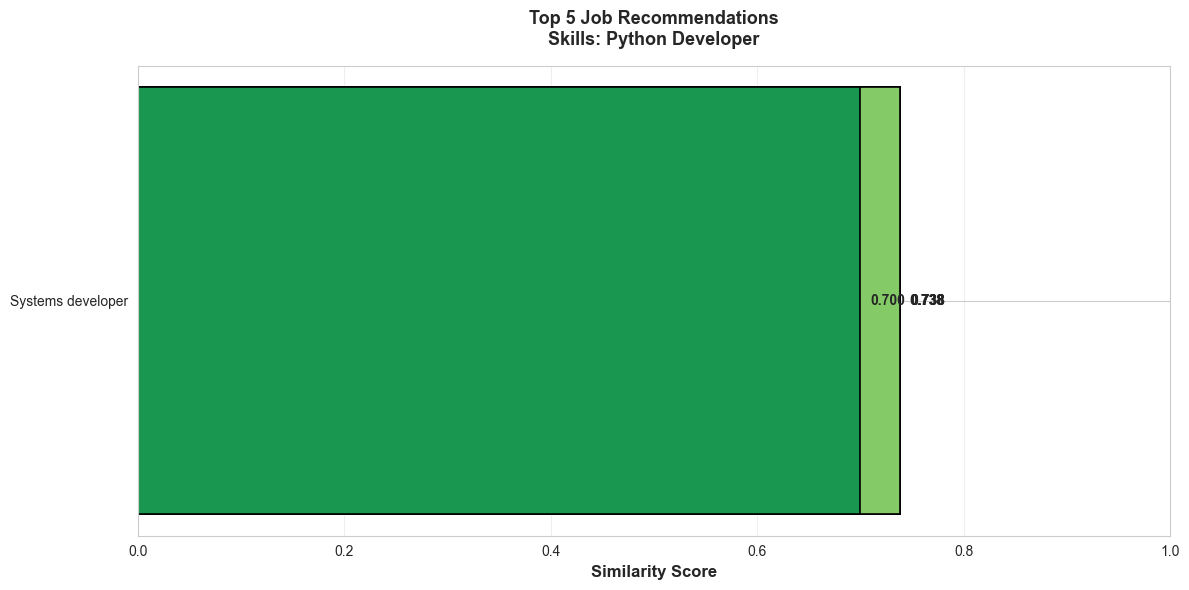

In [30]:
os.makedirs('graphs', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))
job_titles = [rec['job_title'][:40] + '...' if len(rec['job_title']) > 40 else rec['job_title'] for rec in recommendations]
scores_plot = [rec['similarity_score'] for rec in recommendations]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(scores_plot)))

bars = ax.barh(job_titles, scores_plot, color=colors, edgecolor='black', linewidth=1.2)
for i, (bar, score) in enumerate(zip(bars, scores_plot)):
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.3f}', va='center', fontweight='bold')

ax.set_xlabel('Similarity Score', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Job Recommendations\nSkills: ' + user_input[:60], fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/01_top_5_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()

### Graph 2: Similarity Score Distribution

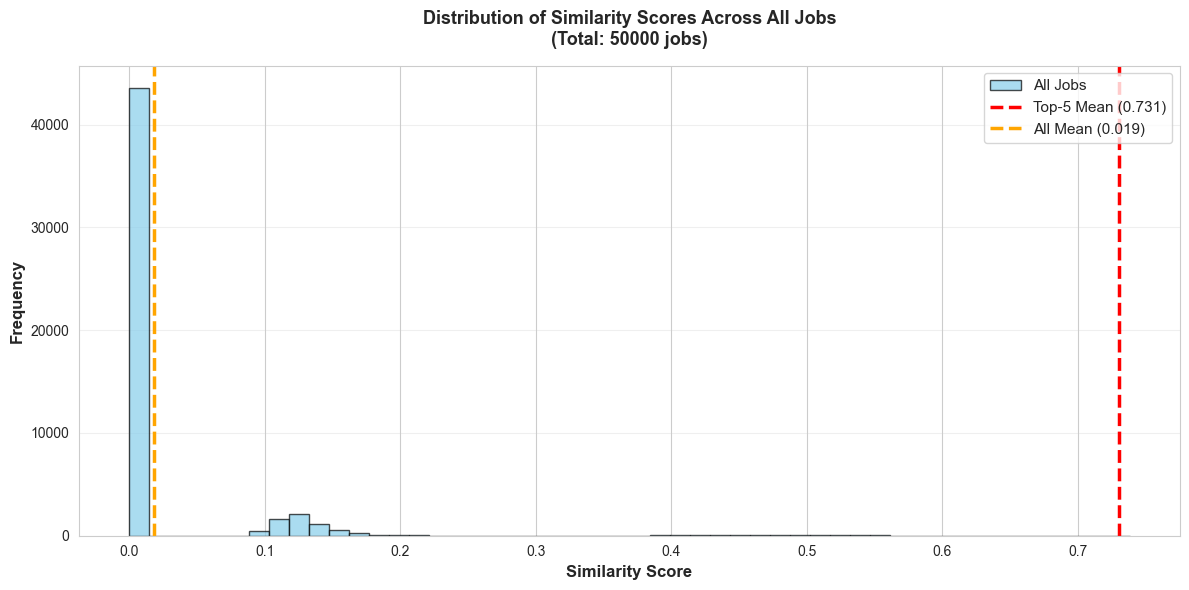

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(all_similarities, bins=50, alpha=0.7, color='skyblue', edgecolor='black', label='All Jobs')
ax.axvline(np.mean(scores), color='red', linestyle='--', linewidth=2.5, label=f'Top-5 Mean ({np.mean(scores):.3f})')
ax.axvline(np.mean(all_similarities), color='orange', linestyle='--', linewidth=2.5, label=f'All Mean ({np.mean(all_similarities):.3f})')
ax.set_xlabel('Similarity Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Distribution of Similarity Scores Across All Jobs\n(Total: {len(all_similarities)} jobs)', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/02_similarity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Graph 3: Top Skills in Dataset

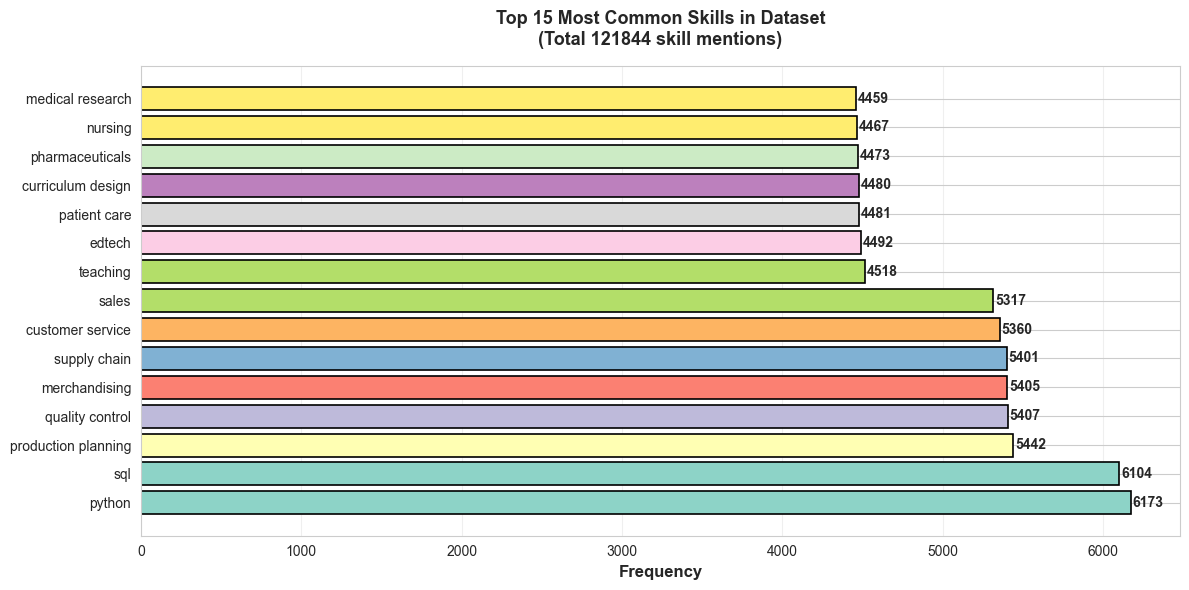

✓ All graphs generated and saved to graphs/ folder!


In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
all_skills = []
for skills_str in system.jobs_data['required_skills']:
    if isinstance(skills_str, str):
        skills = [s.strip().lower() for s in skills_str.split(',')]
        all_skills.extend(skills)

skill_counts = Counter(all_skills)
top_skills = dict(skill_counts.most_common(15))
skills_list = list(top_skills.keys())
counts_list = list(top_skills.values())
colors_skills = plt.cm.Set3(np.linspace(0, 1, len(skills_list)))

bars = ax.barh(skills_list, counts_list, color=colors_skills, edgecolor='black', linewidth=1.2)
for bar, count in zip(bars, counts_list):
    ax.text(count + 10, bar.get_y() + bar.get_height()/2, f'{int(count)}', va='center', fontweight='bold')

ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Top 15 Most Common Skills in Dataset\n(Total {len(all_skills)} skill mentions)', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/03_top_skills.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ All graphs generated and saved to graphs/ folder!')

## Phase 8: Results & Analysis

In [33]:
best_job = recommendations[0]
best_score = best_job['similarity_score']

print(f'🏆 Top Recommendation:')
print(f'  • Job: {best_job["job_title"]}')
print(f'  • Company: {best_job["company"]}')
print(f'  • Match Score: {best_score:.4f} ({best_score*100:.2f}%)')
print(f'  • Why? Strong alignment between your skills and job requirements')

user_skills = set(s.strip().lower() for s in user_input.split(','))
matched_skills_all = []
for rec in recommendations:
    if rec.get('matched_skills'):
        matched_skills_all.extend(rec['matched_skills'])

print(f'\n💡 Key Insights:')
print(f'  • Your skills: {", ".join(user_skills)}')
print(f'  • Matched in recommendations: {", ".join(set(matched_skills_all)) if matched_skills_all else "N/A"}')
print(f'  • Average match quality: {evaluation_data["avg_top5"]:.1%}')
print(f'  • System inference time: {inference_time*1000:.2f}ms')

print(f'\n📊 Dataset Overview:')
print(f'  • Total jobs analyzed: {len(system.jobs_data)}')
print(f'  • Feature dimensions: {system.job_vectors.shape[1]}')

print(f'\n✅ System Summary:')
print(f'  • Status: {evaluation_data["quality"]}')
print(f'  • Processing time: {inference_time*1000:.2f}ms')
print(f'\n🎉 PIPELINE EXECUTION COMPLETE!')

🏆 Top Recommendation:
  • Job: Systems developer
  • Company: Gallagher-Rivera
  • Match Score: 0.7384 (73.84%)
  • Why? Strong alignment between your skills and job requirements

💡 Key Insights:
  • Your skills: python developer
  • Matched in recommendations: python
  • Average match quality: 73.1%
  • System inference time: 87.07ms

📊 Dataset Overview:
  • Total jobs analyzed: 50000
  • Feature dimensions: 552

✅ System Summary:
  • Status: EXCELLENT - Strong skill matches found
  • Processing time: 87.07ms

🎉 PIPELINE EXECUTION COMPLETE!
